Loading data...
Cleaning and preprocessing data...
Engineering features...
Preparing data for modeling...
Training data shape: (34678, 9)
Testing data shape: (8670, 9)
Training the XGBoost model...


c:\Users\erwin\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:41:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluating the model...

Classification Report:
              precision    recall  f1-score   support

  Not Top 10       0.96      0.98      0.97      7973
      Top 10       0.71      0.55      0.62       697

    accuracy                           0.95      8670
   macro avg       0.83      0.77      0.80      8670
weighted avg       0.94      0.95      0.94      8670


Confusion Matrix:


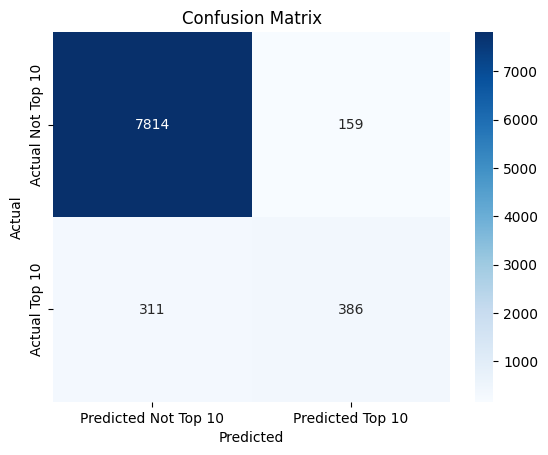


Analyzing feature importances...


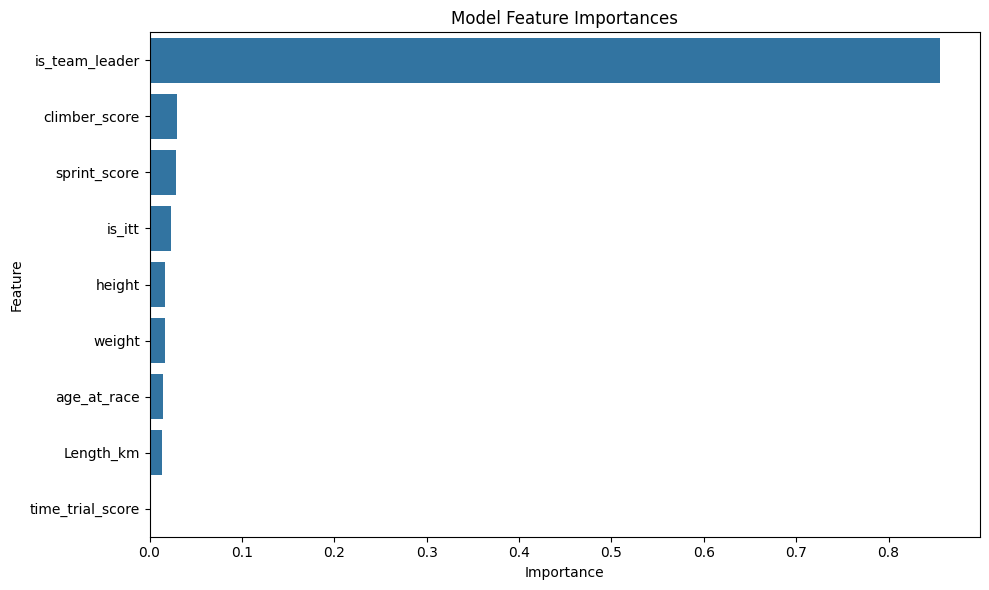


✅ Model prototype script finished.


In [2]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import ast

# --- 1. Data Loading ---

print("Loading data...")
# Load the datasets as defined in your notebook
db_path = "../../data/cycling_big.db"
riders_csv_path = "../../data/data/rider_infos.csv"

ride_info = pd.read_csv(riders_csv_path)
conn = sqlite3.connect(db_path)
race_results = pd.read_sql_query("SELECT * FROM race_results", conn)
conn.close()

# --- 2. Data Cleaning & Preprocessing ---

print("Cleaning and preprocessing data...")

def clean_race_data(df):
    """Cleans the main race results DataFrame."""
    # Convert 'Rnk' to a numeric type, setting non-numeric values (like 'DNF') to NaN
    df['Rnk_numeric'] = pd.to_numeric(df['Rnk'], errors='coerce')
    
    # Convert 'Date' to datetime objects
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # Clean 'Length' column by removing 'km' and converting to numeric
    df['Length_km'] = pd.to_numeric(df['Length'].str.replace('km', ''), errors='coerce')
    
    # Drop original and useless columns
    df = df.drop(columns=['Rnk', 'Length', 'UCI', 'Pnt', 'Circuit', 'Category'])
    
    # Drop rows with no valid rank or date, as they are unusable
    df = df.dropna(subset=['Rnk_numeric', 'Date'])
    
    return df

race_results_clean = clean_race_data(race_results)

# Merge the two datasets
df = pd.merge(race_results_clean, ride_info, left_on='Rider', right_on='fullname', how='left')

# --- 3. Feature Engineering ---

print("Engineering features...")

# Engineer age at the time of the race
df['birthdate'] = pd.to_datetime(df['birthdate'], errors='coerce')
df['age_at_race'] = (df['Date'] - df['birthdate']).dt.days / 365.25

# Engineer team roles (Leader vs. Domestique)
# We find the best rank for each team on each stage using groupby().transform()
df['best_team_rank_in_stage'] = df.groupby(['Race_ID', 'Stage_Number', 'Team'])['Rnk_numeric'].transform('min')
df['is_team_leader'] = (df['Rnk_numeric'] == df['best_team_rank_in_stage']).astype(int)

# Engineer rider specialty scores from the 'pps' column
def get_skill_score(pps_string, skill):
    try:
        pps_dict = ast.literal_eval(str(pps_string))
        return pps_dict.get(skill, 0)
    except (ValueError, SyntaxError):
        return 0

df['climber_score'] = df['pps'].apply(lambda x: get_skill_score(x, 'Climber'))
df['sprint_score'] = df['pps'].apply(lambda x: get_skill_score(x, 'Sprint'))
df['time_trial_score'] = df['pps'].apply(lambda x: get_skill_score(x, 'TimeTrial'))

# Convert 'Stage_Type' to a numerical feature
df['is_itt'] = (df['Stage_Type'] == 'ITT').astype(int)

# --- 4. Model Preparation ---

print("Preparing data for modeling...")

# Define the Target Variable (y): Predict if a rider will finish in the top 10
df['is_top_10'] = (df['Rnk_numeric'] <= 10).astype(int)

# Define Features (X)
# Select only the features that are useful for prediction
feature_names = [
    'age_at_race',
    'Length_km',
    'is_team_leader',
    'climber_score',
    'sprint_score',
    'time_trial_score',
    'is_itt',
    'height',
    'weight'
]

# Drop rows where critical features are missing for the model
df_model = df.dropna(subset=feature_names + ['is_top_10'])

X = df_model[feature_names]
y = df_model['is_top_10']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# --- 5. Model Pipeline & Training ---

print("Training the XGBoost model...")

# Create a scikit-learn pipeline
# This handles missing values (imputation) and then trains the model
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # Fills missing height/weight with the average
    ('scaler', StandardScaler()),                 # Scales features to have similar ranges
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Train the entire pipeline on the training data
pipeline.fit(X_train, y_train)

# --- 6. Model Evaluation ---

print("Evaluating the model...")

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Top 10', 'Top 10']))

# Display a confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Not Top 10', 'Predicted Top 10'], yticklabels=['Actual Not Top 10', 'Actual Top 10'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


# --- 7. Feature Importance ---

print("\nAnalyzing feature importances...")

# Get feature importances from the trained model
importances = pipeline.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Model Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n✅ Model prototype script finished.")

In [5]:
X

,age_at_race,Length_km,is_team_leader,climber_score,sprint_score,time_trial_score,is_itt,height,weight
0,29.505818,149.0,1,700,15910,0,0,1.84,80.0
2,26.910335,149.0,1,103,1050,0,0,1.87,74.0
3,31.312799,149.0,1,1478,7838,0,0,1.83,71.0
7,29.237509,149.0,1,68,4598,0,0,1.79,74.0
8,26.258727,149.0,0,273,4598,0,0,1.75,72.0
...,...,...,...,...,...,...,...,...,...
74948,26.275154,0.0,0,94,46,0,0,1.83,67.0
74949,38.499658,0.0,0,701,0,0,0,1.77,68.0
74951,38.707734,0.0,0,42,1081,0,0,1.83,72.0
74952,27.378508,0.0,0,1135,465,0,0,1.82,70.0
